# 44 — Re-downsample with the fixed BOX resampler (and rebuild the MDS)

Notebook 37 retargeted the downsampled masks to **44×18**, but it used the old floor-division
`downsample`, which **truncates instead of interpolating**:

```
H, W = 104, 256   out_h, out_w = 18, 44
block_h = 104 // 18 = 5     block_w = 256 // 44 = 5
covered = 90 x 220  ->  drops the bottom 14 rows (13.5% of H) and right 36 cols (14.1% of W)
```

Only the top-left 90×220 region of the 104×256 segment mask was block-averaged, so when the
predicted downsampled mask is scaled back up over the original image it lands in the wrong place
(see notebook 41 — old red contour vs fixed cyan contour).

`downsample` in `src3/overhead_pipeline.py` is now:

```python
def downsample(mask: Image.Image, out_h: int, out_w: int) -> Image.Image:
    # BOX resampling area-averages over the full H x W mask (unlike a floor-division block
    # reshape, which silently truncates ... whenever out_h/out_w don't evenly divide H/W).
    return mask.resize((out_w, out_h), resample=Image.BOX)
```

This notebook re-runs the notebook-37 fix with the new function — same 18×44 target, same
output→samples fan-out, idempotent — then **rebuilds the MDS dataset**.

> **Output → many samples.** Outputs are shared: every speaker capture of the same object/position
> symlinks the same `outputs/<output_id>/` artifacts. `fix_downsample` takes an **output_id**,
> re-downsamples the full-res `02_segment_mask.png` (256×104) once, then fans the metadata update
> + re-symlink out to every sample in that output's `samples.jsonl`.

Per output, updated in `outputs/<output_id>/` **and** each linked `samples/<sample_id>/`:
- `03_downsampled_segment_mask.png` — new BOX-resampled 44×18 mask
- `y.npy` — new (18, 44) float mask in [0, 1]
- `04_com.jsonl` — `com` unchanged, `downsampled_com` recomputed on the new mask
- `metadata.jsonl` — `out_h`, `out_w`, `downsampled_com`
- re-establishes each sample→output symlink

> **MDS rebuild needs `force=True`.** `prep_dataset` caches on a hash of
> `(data_dir, sample_ids, MDS_COLUMNS)`. None of those change here — only the *contents* of
> `y.npy` — so without `force=True` it would cache-hit and return the stale shards.

In [1]:
import sys
import inspect
from pathlib import Path
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "src3"))
from overhead_pipeline import downsample, center_of_mass
from io_utils import load, save, symlink, preview_image

DATA_DIR = Path(r"D:\eturok\experiment-22\data")
OUT_H, OUT_W = 18, 44  # (H, W): unchanged from notebook 37 — only the resampling method changes

FIXED_SAMPLE_IDS = []  # every fix_downsample(do_save=True) call appends the sample ids it updated

# guard: refuse to run against the old floor-division implementation
src = inspect.getsource(downsample)
print(src)
assert "Image.BOX" in src, "src3/overhead_pipeline.py still has the old floor-division downsample!"

def downsample(mask: Image.Image, out_h: int, out_w: int) -> Image.Image:
    # BOX resampling area-averages over the full H x W mask (unlike a floor-division block
    # reshape, which silently truncates to block_h*out_h x block_w*out_w and drops the
    # bottom/right edge whenever out_h/out_w don't evenly divide H/W).
    return mask.resize((out_w, out_h), resample=Image.BOX)



In [2]:
def update_metadata_keys(path: Path, updates: dict, do_save: bool = True):
    """metadata.jsonl is one single-key dict per line. Overwrite the lines whose key is in
    `updates`; append any keys that weren't already present. Leaves all other lines intact."""
    if not do_save:
        return
    rows = load(path)  # list[dict]
    seen = set()
    for row in rows:
        for k in row:
            if k in updates:
                row[k] = updates[k]
                seen.add(k)
    for k, v in updates.items():
        if k not in seen:
            rows.append({k: v})
    save(rows, path)


def fix_downsample(output_id: str, data_dir: Path = DATA_DIR, out_h: int = OUT_H, out_w: int = OUT_W, do_save: bool = True):
    """Re-downsample one shared OUTPUT's segment mask to (out_h, out_w) with the fixed BOX
    resampler, then propagate to every sample that references it. Idempotent — safe to re-run."""
    output_dir = data_dir / "outputs" / output_id

    meta = {k: v for d in load(output_dir / "metadata.jsonl") for k, v in d.items()}
    is_empty_box = bool(meta.get("is_empty_box", False))

    # 1. re-downsample the FULL-RES segment mask (256x104) -> (out_h, out_w)
    segment_mask = load(output_dir / "02_segment_mask.png")
    downsampled_mask = downsample(segment_mask, out_h, out_w)
    save(downsampled_mask, output_dir / "03_downsampled_segment_mask.png", do_save)

    # 2. y.npy: float mask in [0, 1]
    y = np.array(downsampled_mask, dtype=np.float32) / 255.0
    save(y, output_dir / "y.npy", do_save)

    # 3. recompute downsampled_com on the new mask (com on the full mask is unchanged)
    com = load(output_dir / "04_com.jsonl")[0]["com"]
    downsampled_com = (-1, -1) if is_empty_box else center_of_mass(downsampled_mask)
    save({"com": com, "downsampled_com": downsampled_com}, output_dir / "04_com.jsonl", do_save)

    # 4. update the output's metadata
    updates = {"out_h": out_h, "out_w": out_w, "downsampled_com": list(downsampled_com)}
    update_metadata_keys(output_dir / "metadata.jsonl", updates, do_save)

    # 5. fan out to EVERY sample sharing this output: update metadata + re-symlink
    sample_ids = sorted({r["sample_id"] for r in load(output_dir / "samples.jsonl") if "sample_id" in r})
    for sid in sample_ids:
        sample_dir = data_dir / "samples" / sid
        update_metadata_keys(sample_dir / "metadata.jsonl", updates, do_save)
        symlink(output_dir / "y.npy", sample_dir / "y.npy", do_save)
        symlink(output_dir / "03_downsampled_segment_mask.png", sample_dir / "outputs/03_downsampled_segment_mask.png", do_save)
        symlink(output_dir / "04_com.jsonl", sample_dir / "outputs/04_com.jsonl", do_save)

    # record what we actually fixed (only real writes) so we can audit coverage at the end
    if do_save:
        FIXED_SAMPLE_IDS.extend(sample_ids)

    print(f"[output {output_id}] y -> {y.shape} (H,W)  out_h={out_h} out_w={out_w}  "
          f"downsampled_com={tuple(round(c, 2) for c in downsampled_com)}  "
          f"| updated {len(sample_ids)} sample(s): {sample_ids}")
    return y, downsampled_com

## Old vs new on one output (does not write)

Left to right: full-res segment mask → the mask currently on disk (floor-division, truncated) →
the new BOX-resampled mask → |new − old|. The difference concentrates toward the bottom/right,
where the old code dropped 14 rows / 36 cols.

> If this notebook has already been run, "old (on disk)" is already the BOX version and the
> difference panel is all zeros — that's the idempotency check, not a bug.

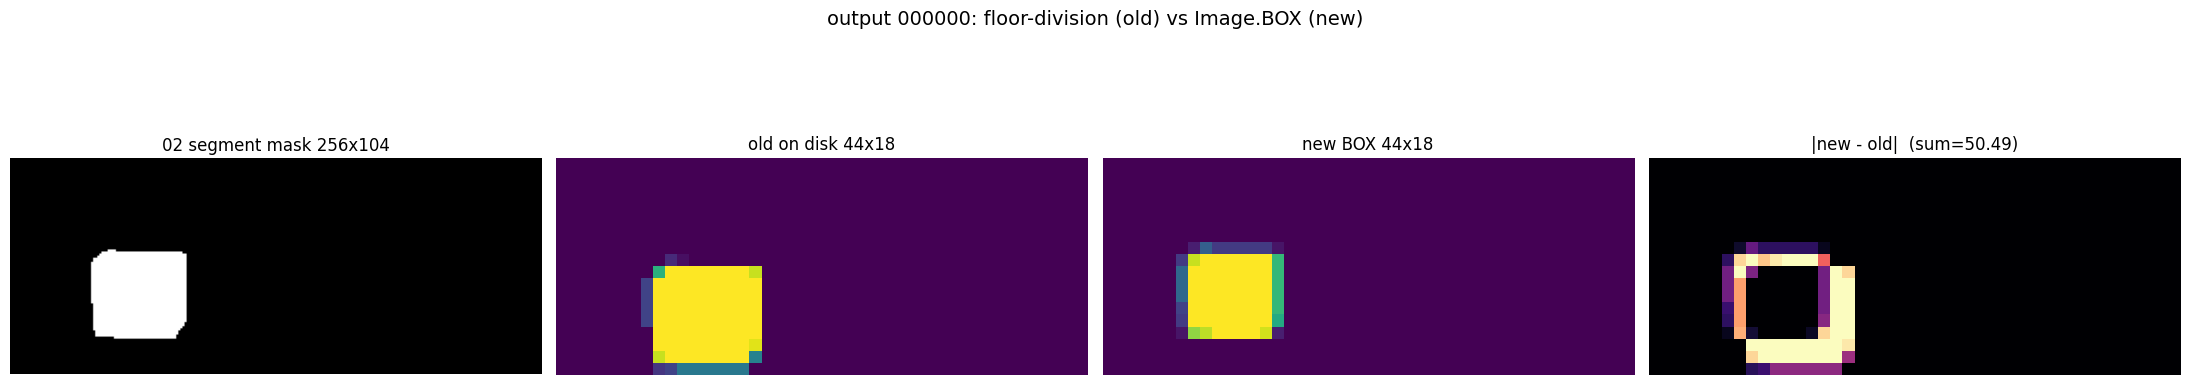

[output 000000] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.85, 10.19)  | updated 8 sample(s): ['000000', '000001', '000002', '000003', '000004', '000005', '000006', '000007']
new y shape (H,W): (18, 44) | sum: 55.49 | downsampled_com: (10.846067607151346, 10.19294720706949)


In [3]:
import matplotlib.pyplot as plt


def compare_old_new(output_id: str, data_dir: Path = DATA_DIR):
    od = data_dir / "outputs" / output_id
    seg = np.array(load(od / "02_segment_mask.png"), dtype=np.float32) / 255.0
    old = np.array(load(od / "03_downsampled_segment_mask.png"), dtype=np.float32) / 255.0
    new = np.array(downsample(load(od / "02_segment_mask.png"), OUT_H, OUT_W), dtype=np.float32) / 255.0

    panels = [
        (f"02 segment mask {seg.shape[1]}x{seg.shape[0]}", seg, "gray"),
        (f"old on disk {old.shape[1]}x{old.shape[0]}", old, "viridis"),
        (f"new BOX {new.shape[1]}x{new.shape[0]}", new, "viridis"),
        (f"|new - old|  (sum={np.abs(new - old).sum():.2f})", np.abs(new - old), "magma"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, (title, img, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"output {output_id}: floor-division (old) vs Image.BOX (new)", fontsize=14)
    plt.tight_layout()
    plt.show()


compare_old_new("000000")
y, dcom = fix_downsample("000000", do_save=False)  # dry run: computes, writes nothing
print("new y shape (H,W):", y.shape, "| sum:", round(float(y.sum()), 2), "| downsampled_com:", dcom)

## Run for real on one output

Re-running is idempotent. `000000` fans out to its sibling samples `000001`–`000007`.

In [4]:
_ = fix_downsample("000000", do_save=True)

[output 000000] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.85, 10.19)  | updated 8 sample(s): ['000000', '000001', '000002', '000003', '000004', '000005', '000006', '000007']


## Run for every output

Iterates over **output** ids (each fans out to all its samples).

In [5]:
FIXED_SAMPLE_IDS.clear()  # fresh accounting for this full pass
output_ids = sorted(p.name for p in (DATA_DIR / "outputs").iterdir() if p.is_dir())
print(f"{len(output_ids)} outputs")
for oid in output_ids:
    fix_downsample(oid, do_save=True)

86 outputs
[output 000000] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.85, 10.19)  | updated 8 sample(s): ['000000', '000001', '000002', '000003', '000004', '000005', '000006', '000007']
[output 000001] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(6.88, 10.25)  | updated 8 sample(s): ['000008', '000009', '000010', '000011', '000012', '000013', '000014', '000015']
[output 000002] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.31, 10.23)  | updated 8 sample(s): ['000016', '000017', '000018', '000019', '000020', '000021', '000022', '000023']
[output 000003] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.73, 13.29)  | updated 8 sample(s): ['000024', '000025', '000026', '000027', '000028', '000029', '000030', '000031']
[output 000004] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.24, 13.1)  | updated 8 sample(s): ['000032', '000033', '000034', '000035', '000036', '000037', '000038', '000039']
[output 000005] y -> (18, 44) (H,

[output 000006] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.46, 14.14)  | updated 8 sample(s): ['000048', '000049', '000050', '000051', '000052', '000053', '000054', '000055']
[output 000007] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.01, 13.66)  | updated 8 sample(s): ['000056', '000057', '000058', '000059', '000060', '000061', '000062', '000063']


[output 000008] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.25, 14.17)  | updated 8 sample(s): ['000064', '000065', '000066', '000067', '000068', '000069', '000070', '000071']
[output 000009] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.53, 16.79)  | updated 8 sample(s): ['000072', '000073', '000074', '000075', '000076', '000077', '000078', '000079']
[output 000010] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.62, 16.5)  | updated 8 sample(s): ['000080', '000081', '000082', '000083', '000084', '000085', '000086', '000087']
[output 000011] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.61, 16.25)  | updated 8 sample(s): ['000088', '000089', '000090', '000091', '000092', '000093', '000094', '000095']
[output 000012] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.43, 18.66)  | updated 8 sample(s): ['000096', '000097', '000098', '000099', '000100', '000101', '000102', '000103']
[output 000013] y -> (18, 44) (H,W)  out_h=1

[output 000015] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.78, 20.88)  | updated 8 sample(s): ['000120', '000121', '000122', '000123', '000124', '000125', '000126', '000127']
[output 000016] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(8.12, 20.85)  | updated 8 sample(s): ['000128', '000129', '000130', '000131', '000132', '000133', '000134', '000135']


[output 000017] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.51, 20.71)  | updated 8 sample(s): ['000136', '000137', '000138', '000139', '000140', '000141', '000142', '000143']
[output 000018] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.39, 23.99)  | updated 8 sample(s): ['000144', '000145', '000146', '000147', '000148', '000149', '000150', '000151']
[output 000019] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.8, 23.79)  | updated 8 sample(s): ['000152', '000153', '000154', '000155', '000156', '000157', '000158', '000159']
[output 000020] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.78, 23.66)  | updated 8 sample(s): ['000160', '000161', '000162', '000163', '000164', '000165', '000166', '000167']
[output 000021] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.68, 26.29)  | updated 8 sample(s): ['000168', '000169', '000170', '000171', '000172', '000173', '000174', '000175']
[output 000022] y -> (18, 44) (H,W)  out_h=1

...

[output 000062] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(8.19, 13.89)  | updated 8 sample(s): ['000496', '000497', '000498', '000499', '000500', '000501', '000502', '000503']
[output 000063] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(8.85, 36.53)  | updated 8 sample(s): ['000504', '000505', '000506', '000507', '000508', '000509', '000510', '000511']
[output 000064] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(6.47, 30.25)  | updated 8 sample(s): ['000512', '000513', '000514', '000515', '000516', '000517', '000518', '000519']
[output 000065] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(9.67, 27.8)  | updated 8 sample(s): ['000520', '000521', '000522', '000523', '000524', '000525', '000526', '000527']
[output 000066] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.74, 35.66)  | updated 8 sample(s): ['000528', '000529', '000530', '000531', '000532', '000533', '000534', '000535']
[output 000067] y -> (18, 44) (H,W)  out_h=18 

[output 000069] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(9.42, 13.96)  | updated 8 sample(s): ['000552', '000553', '000554', '000555', '000556', '000557', '000558', '000559']
[output 000070] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(9.97, 30.92)  | updated 8 sample(s): ['000560', '000561', '000562', '000563', '000564', '000565', '000566', '000567']


[output 000071] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(10.91, 34.72)  | updated 8 sample(s): ['000568', '000569', '000570', '000571', '000572', '000573', '000574', '000575']
[output 000072] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(6.87, 21.36)  | updated 8 sample(s): ['000576', '000577', '000578', '000579', '000580', '000581', '000582', '000583']
[output 000073] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(9.82, 10.49)  | updated 8 sample(s): ['000584', '000585', '000586', '000587', '000588', '000589', '000590', '000591']
[output 000074] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.18, 9.1)  | updated 8 sample(s): ['000592', '000593', '000594', '000595', '000596', '000597', '000598', '000599']
[output 000075] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(6.66, 21.33)  | updated 8 sample(s): ['000600', '000601', '000602', '000603', '000604', '000605', '000606', '000607']
[output 000076] y -> (18, 44) (H,W)  out_h=18 

[output 000078] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(8.48, 26.87)  | updated 8 sample(s): ['000624', '000625', '000626', '000627', '000628', '000629', '000630', '000631']
[output 000079] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.44, 10.59)  | updated 8 sample(s): ['000632', '000633', '000634', '000635', '000636', '000637', '000638', '000639']


[output 000080] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(4.27, 16.82)  | updated 8 sample(s): ['000640', '000641', '000642', '000643', '000644', '000645', '000646', '000647']
[output 000081] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.21, 22.74)  | updated 8 sample(s): ['000648', '000649', '000650', '000651', '000652', '000653', '000654', '000655']
[output 000082] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(7.7, 26.55)  | updated 8 sample(s): ['000656', '000657', '000658', '000659', '000660', '000661', '000662', '000663']
[output 000083] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(-1, -1)  | updated 8 sample(s): ['000664', '000665', '000666', '000667', '000668', '000669', '000670', '000671']
[output 000084] y -> (18, 44) (H,W)  out_h=18 out_w=44  downsampled_com=(-1, -1)  | updated 8 sample(s): ['000672', '000673', '000674', '000675', '000676', '000677', '000678', '000679']
[output 000085] y -> (18, 44) (H,W)  out_h=18 out_w=44  

## Audit — did we fix every sample?

Compares the accumulated `FIXED_SAMPLE_IDS` against every sample dir on disk and reports anything missed.

In [6]:
all_sample_ids = sorted(p.name for p in (DATA_DIR / "samples").iterdir() if p.is_dir())
fixed = set(FIXED_SAMPLE_IDS)

missing = [s for s in all_sample_ids if s not in fixed]          # on disk but never fixed
orphans = sorted(fixed - set(all_sample_ids))                    # fixed but no sample dir on disk
dupes = sorted({s for s in FIXED_SAMPLE_IDS if FIXED_SAMPLE_IDS.count(s) > 1})  # fixed >1x

print(f"samples on disk    : {len(all_sample_ids)}")
print(f"fixed (calls)      : {len(FIXED_SAMPLE_IDS)}")
print(f"fixed (unique)     : {len(fixed)}")
print(f"missing (not fixed): {len(missing)}  {missing}")
if orphans: print(f"fixed but no dir   : {orphans}")
if dupes:   print(f"fixed more than once: {dupes}")
print("\n" + ("\u2705 every sample fixed" if not missing else f"\u274c {len(missing)} sample(s) NOT fixed"))

samples on disk    : 688
fixed (calls)      : 688
fixed (unique)     : 688
missing (not fixed): 0  []

✅ every sample fixed


## Rebuild the MDS dataset

`prep_dataset` cache-keys on `(data_dir, sample_ids, MDS_COLUMNS)` — all unchanged here — so
`force=True` is **required**: it deletes the cached shard dir and rewrites it with the new `y`
(and the recomputed `downsampled_com_x/y`) for every sample.

In [7]:
from dataset import prep_dataset

mds_path = prep_dataset(DATA_DIR, force=True, verbose=2)
print("MDS rebuilt at:", mds_path)

W0706 10:17:53.486000 37284 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


C:\Users\eitanturok\good-vibrations\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 688 complete samples (0 skipped, missing X.npy)
skipped ids: []
--force: deleting cached MDS at D:\eturok\experiment-22\data\mds\c1650bbbf41d93b8 and rebuilding
Writing MDS to D:\eturok\experiment-22\data\mds\c1650bbbf41d93b8 ...


  wrote 50/688


  wrote 100/688


...

  wrote 500/688


  wrote 550/688


  wrote 600/688


  wrote 650/688


Wrote 688 samples. data_info={'out_h': 18, 'out_w': 44, 'n_samples': 688, 'n_laser_rows': 10, 'n_laser_cols': 10, 'patch_size': 256, 'n_freqs': 3328}
MDS: D:\eturok\experiment-22\data\mds\c1650bbbf41d93b8 (688 samples)
MDS rebuilt at: D:\eturok\experiment-22\data\mds\c1650bbbf41d93b8


## Verify the MDS matches disk

Spot-check a few MDS rows: `y` must be bit-identical to the sample's `y.npy` on disk (which now
resolves, via symlink, to the BOX-resampled output mask), and `downsampled_com` must match metadata.

In [8]:
from dataset import VibrationDataset

ds = VibrationDataset(local=mds_path)
print(f"{len(ds)} samples in MDS")

rng = np.random.default_rng(0)
for idx in sorted(rng.choice(len(ds), size=min(5, len(ds)), replace=False).tolist()):
    s = ds[idx]
    sid = f"{s['info']['sample_id']:06d}"
    y_mds = s["mask_true"].numpy()
    y_disk = np.load(DATA_DIR / "samples" / sid / "y.npy")
    assert y_mds.shape == (OUT_H, OUT_W), f"{sid}: y shape {y_mds.shape} != {(OUT_H, OUT_W)}"
    assert np.array_equal(y_mds, y_disk), f"{sid}: MDS y != on-disk y.npy"
    meta_com = {k: v for d in load(DATA_DIR / 'samples' / sid / 'metadata.jsonl') for k, v in d.items()}["downsampled_com"]
    assert np.allclose([s["info"]["x_com"], s["info"]["y_com"]], meta_com), f"{sid}: MDS com != metadata com"
    print(f"sample {sid}: y {y_mds.shape} identical to disk, com matches \u2713")

print("\n\u2705 MDS verified against disk")

688 samples in MDS
sample 000185: y (18, 44) identical to disk, com matches ✓
sample 000211: y (18, 44) identical to disk, com matches ✓
sample 000350: y (18, 44) identical to disk, com matches ✓
sample 000436: y (18, 44) identical to disk, com matches ✓
sample 000581: y (18, 44) identical to disk, com matches ✓

✅ MDS verified against disk


C:\Users\eitanturok\good-vibrations\src3\dataset.py:137: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  return dict(fft=torch.from_numpy(X), mask_true=torch.from_numpy(y), info=info)


## Visual sanity check

For one `sample_id`, show the pipeline side by side: resized overhead → full-res segment mask →
downsampled mask → the saved `y.npy` → the new mask upscaled (NEAREST) back over the overhead,
which is exactly the overlay that was misaligned before the fix.

C:\Users\eitanturok\AppData\Local\Temp\ipykernel_37284\3182024104.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  up = np.array(Image.fromarray((y * 255).astype(np.uint8), mode="L").resize(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003921568859368563..1.0000000018626451].


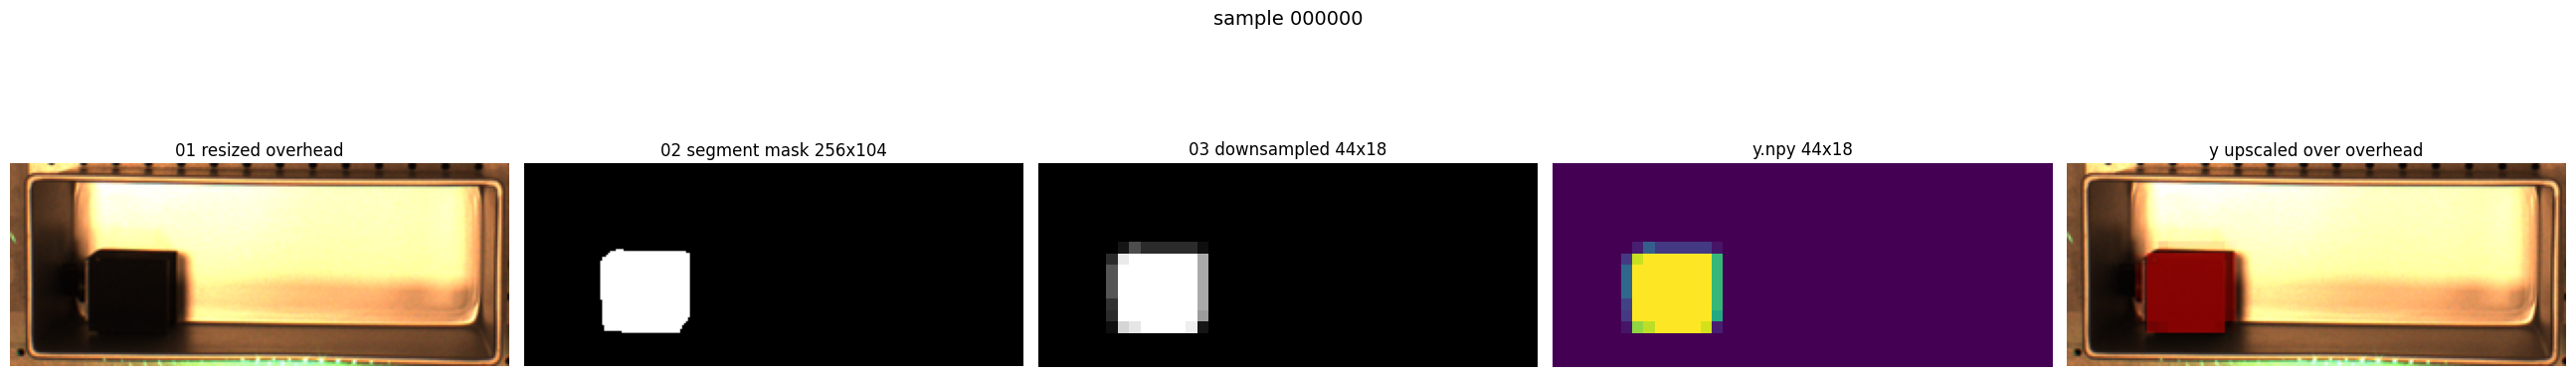

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003921568859368563..1.0000000298023224].


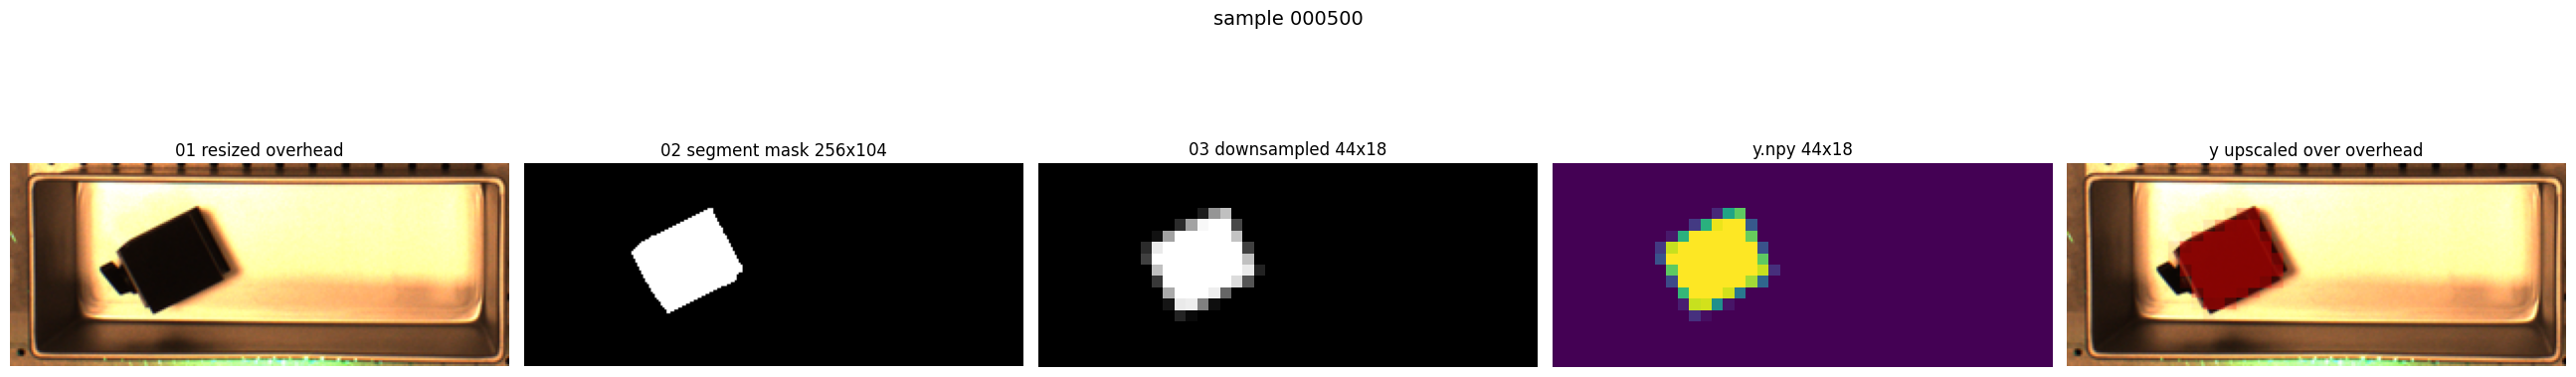

In [9]:
from PIL import Image


def sanity_check(sample_id: str, data_dir: Path = DATA_DIR):
    sd = data_dir / "samples" / sample_id
    resized = np.array(load(sd / "outputs/01_resized_overhead.png"))
    seg = np.array(load(sd / "outputs/02_segment_mask.png"))
    down = np.array(load(sd / "outputs/03_downsampled_segment_mask.png"))
    y = np.load(sd / "y.npy")

    # upscale the downsampled mask back to the overhead size and overlay in red — this is the
    # view that exposed the floor-division bug
    up = np.array(Image.fromarray((y * 255).astype(np.uint8), mode="L").resize(
        (resized.shape[1], resized.shape[0]), resample=Image.NEAREST), dtype=np.float32) / 255.0
    overlay = resized.astype(np.float32) / 255.0
    overlay = overlay * (1 - 0.5 * up[..., None]) + 0.5 * up[..., None] * np.array([1.0, 0.0, 0.0])

    panels = [
        ("01 resized overhead", resized, None),
        (f"02 segment mask {seg.shape[1]}x{seg.shape[0]}", seg, "gray"),
        (f"03 downsampled {down.shape[1]}x{down.shape[0]}", down, "gray"),
        (f"y.npy {y.shape[1]}x{y.shape[0]}", y, "viridis"),
        ("y upscaled over overhead", overlay, None),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(26, 5))
    for ax, (title, img, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap, vmin=0 if cmap else None, vmax=1 if cmap == "viridis" else None)
        ax.set_title(title)
        ax.axis("off")
    fig.suptitle(f"sample {sample_id}", fontsize=14)
    plt.tight_layout()
    plt.show()


sanity_check("000000")
sanity_check("000500")